In [1]:
import numpy as np
import sys
from pathlib import Path

sys.path.append('../code/')

from mlalgos import HyperOpt
from mllib import Utilities,MLUtilities

from time import time
import copy,pickle

import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.colors as pltcol
import gc

ut = Utilities()
ml = MLUtilities()

In [2]:
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14 # 14
mpl.rcParams['legend.labelspacing'] = 0.25
FS = 18
FS2 = 15
FS3 = 14
FSS = 12
FSL = 22

mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.size'] = 3

#mpl.rcParams.keys()

# Example usage of `AutoEncoder`  
### using `Sequential` with `HyperOpt` for optimization

## Examples: MNIST, SVD

In [3]:
Example = 'svd' # 'mnist','svd'

if Example == 'mnist':
    Downsample = 0.1  # 1.0 is doable on desktop: reaches ~59.6GB RAM using N = 3 x 48 jobs, scales ~ 1/N
    Select_k = [0,1]  # list of digits to include in data
    K = len(Select_k) # number of digits included  
if Example == 'svd':
    NonLinear = True  # whether or not to implement nonlinearity.
    D = 15            # dimensionality. Set >= 2 for interesting problems
    n_rot = 10        # number of rotations to apply [<= (D choose 3)]
    n_NL = 40         # number of pairs of dimensions to combine nonlinearly [<= (D choose 2)]

In [4]:
Out_Stem = 'autoencoder/'
ExDict = {'mnist':{'text':'MNIST', # text will be updated below
                   'nproc':1},     # large mem reqs for MNIST mean 1 is best
          'svd':{'text':'SVD','nproc':16}
         }

if Example not in ExDict.keys():
    raise Exception("Unrecognised example '"+Example+"'")

Out_Stem += Example + '/'
if Example == 'mnist':
    k_dir = 'k' + ''.join([str(k) for k in Select_k])
    k_text = 'k=[' + ','.join([str(k) for k in Select_k]) + ']'
    Out_Stem += k_dir + '/'
    ExDict['mnist']['text'] += " ({0:.0f}%;".format(100*Downsample) + k_text + ')'
if Example == 'svd':
    nl_dir = 'non' if NonLinear else ''
    nl_dir += 'linear/'
    nl_text = '' + nl_dir[:-1]
    Out_Stem += nl_dir
    ExDict['svd']['text'] += ' (' + nl_text + ')'
print(Out_Stem,ExDict[Example]['text'])

Plot_Stem = Out_Stem + 'plots'
Path(Plot_Stem).mkdir(parents=True,exist_ok=True)

Nproc = ExDict[Example]['nproc']

Save_Fig = True

autoencoder/svd/nonlinear/ SVD (nonlinear)


### Data setup

In [5]:
if Example == 'svd':
    from scipy.spatial.transform import Rotation
    import itertools
    
    n_train = 5000
    n_test = 2000
    Show_Dist = False
    
    Seed = 42    
    rng = np.random.RandomState(Seed)

    if NonLinear & (D < 2):
        raise Exception("Nonlinearity can't be implemented in less than 2 dimensions!")
    NL_Pairs = []
    for comb in itertools.combinations(np.arange(D), 2):
        NL_Pairs.append(list(comb))    
    rng.shuffle(NL_Pairs)
    NL_Expos = np.linspace(0.5,2.5,len(NL_Pairs)) # mild to strong nonlinearity
    NL_Amps  = np.logspace(-1.5,-0.5,len(NL_Pairs))[::-1]
    
    # setup covariance matrix with sharply decreasing eigvals
    matrix = np.diagflat(10**np.linspace(0,-(D-1)/2,D))
    # rotate in all combinations of 3-d subspaces
    sl = []
    for comb in itertools.combinations(np.arange(D), 3):
        sl.append(np.ix_(list(comb),list(comb)))    
    rng.shuffle(sl)
    random_rot = Rotation.random(num=len(sl),rng=rng)
    for r in range(np.min([n_rot,len(sl)])):
        rot_mat = random_rot.as_matrix()[r]
        matrix[sl[r]] = np.dot(np.dot(rot_mat,matrix[sl[r]]),rot_mat.T)
        
    X_train = rng.multivariate_normal(np.zeros(D),matrix,size=n_train).T # shape (D,n_train)
    X_test = rng.multivariate_normal(np.zeros(D),matrix,size=n_test).T   # shape (D,n_test)

    if NonLinear:
        for n in range(n_NL):
            X_train[NL_Pairs[n][1]] += NL_Amps[n]*np.fabs(X_train[NL_Pairs[n][0]])**NL_Expos[n]
            X_test[NL_Pairs[n][1]] += NL_Amps[n]*np.fabs(X_test[NL_Pairs[n][0]])**NL_Expos[n]

    if Show_Dist:
        for comb in itertools.combinations(np.arange(D), 2):
            xlab,ylab = mpl.rcParams['xtick.labelsize'],mpl.rcParams['ytick.labelsize']
            axlab = mpl.rcParams['axes.labelsize']
            xmaj,ymaj = mpl.rcParams['xtick.major.size'],mpl.rcParams['ytick.major.size']
            mpl.rcParams['xtick.labelsize'] = 6
            mpl.rcParams['ytick.labelsize'] = 6
            mpl.rcParams['axes.labelsize'] = 8
            mpl.rcParams['xtick.major.size'] = 2
            mpl.rcParams['ytick.major.size'] = 2
            plt.figure(figsize=(1.25,1.25))
            maxlim = np.max([np.fabs(X_train[comb[0]]).max(),np.fabs(X_train[comb[1]]).max()])
            plt.xlim(-maxlim,maxlim)
            plt.ylim(-maxlim,maxlim)
            plt.xlabel("$X_{0:d}$".format(comb[0]))
            plt.ylabel("$X_{0:d}$".format(comb[1]))
            plt.scatter(X_train[comb[0]],X_train[comb[1]],s=0.3)
            plt.show()
            mpl.rcParams['xtick.labelsize'] = xlab
            mpl.rcParams['ytick.labelsize'] = ylab
            mpl.rcParams['axes.labelsize'] = axlab
            mpl.rcParams['xtick.major.size'] = xmaj
            mpl.rcParams['ytick.major.size'] = ymaj

/tmp/ipykernel_362997/2498133320.py:33: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X_train = rng.multivariate_normal(np.zeros(D),matrix,size=n_train).T # shape (D,n_train)
/tmp/ipykernel_362997/2498133320.py:34: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X_test = rng.multivariate_normal(np.zeros(D),matrix,size=n_test).T   # shape (D,n_test)


In [6]:
if Example == 'mnist':
    import tensorflow as tf    
    Vortex = True     # 'vortex unroll' to partially preserve spatial coherence in flattened array
    
    start_time = time()
    (X_train_tf, Y_train_tf), (X_test_tf, Y_test_tf) = tf.keras.datasets.mnist.load_data()
    # Y has category values
    
    print(X_train_tf.shape,X_test_tf.shape)
    print(Y_train_tf.shape,Y_test_tf.shape)

    print('... selecting specified categories')
    print('... ... training samples')
    ind_select = np.array([])
    for k in Select_k:
        ind_select = np.concatenate((ind_select,np.where(Y_train_tf == k)[0]))
    X_train_tf = X_train_tf[ind_select.astype(int)]
    # Y_train_tf = Y_train_tf[ind_select]

    print('... ... test samples')
    ind_select = np.array([])
    for k in Select_k:
        ind_select = np.concatenate((ind_select,np.where(Y_test_tf == k)[0]))
    X_test_tf = X_test_tf[ind_select.astype(int)]
    # Y_test_tf = Y_test_tf[ind_select]

    del Y_train_tf,Y_test_tf
    gc.collect()
    
    if Vortex:
        print('... vortex unroll')
        X_train = ml.vortex_package(X_train_tf.T).astype(float) # (784,nsamp)
        X_test = ml.vortex_package(X_test_tf.T).astype(float) # (784,nsamp)
    else:
        print('... standard flatten')
        X_train = np.zeros((X_train_tf.shape[0],X_train_tf.shape[1]**2))
        for i in range(X_train_tf.shape[0]):
            X_train[i] = X_train_tf[i].flatten()
        X_train = X_train.T
        
        X_test = np.zeros((X_test_tf.shape[0],X_test_tf.shape[1]**2))
        for i in range(X_test_tf.shape[0]):
            X_test[i] = X_test_tf[i].flatten()
        X_test = X_test.T
    
    # don't standardize here, use 'standardize_X' instead
    # X_train /= 255.0
    # X_test /= 255.0

    print(X_train.shape,X_test.shape)
    
    del X_train_tf,X_test_tf
    gc.collect()
    
    print(X_train.shape,X_test.shape)
    
    rng = np.random.RandomState(1991)
    
    n_test = X_test.shape[1]
    if Downsample is None:
        print('... no downsampling')
        n_train = X_train.shape[1]
    else:
        print('... downsampling by factor {0:.3f}'.format(Downsample))
        n_train = int(Downsample*X_train.shape[1])
        ind_train = rng.choice(X_train.shape[1],size=n_train,replace=False)
        X_train = X_train[:,ind_train]
        del ind_train
        
        # comment below 4 to use full test set
        n_test = int(Downsample*X_test.shape[1])  
        ind_test = rng.choice(X_test.shape[1],size=n_test,replace=False)
        X_test = X_test[:,ind_test]
        del ind_test
    
        gc.collect()
    
        print('... retained {0:d} training and {1:d} testing samples'.format(n_train,n_test))
    
    print('... shuffling')
    ind_shuff_train = rng.choice(n_train,size=n_train,replace=False)
    X_train = X_train[:,ind_shuff_train]
    
    ind_shuff_test = rng.choice(n_test,size=n_test,replace=False)
    X_test = X_test[:,ind_shuff_test]
    
    del ind_shuff_train,ind_shuff_test
    gc.collect()
    
    print('... done')
    ut.time_this(start_time)

### Network setup and training

In [7]:
# dictionary containing all setup parameters and data
setup_dict = {} 

# -- data set: features and labels
setup_dict['X'] = X_train

# -- network family and auxiliary params
setup_dict['family'] = 'autoenc'
setup_dict['denoise'] = False
setup_dict['noise_level'] = 0.1 

Out_Dir = Out_Stem + ('default/' if not setup_dict['denoise'] else 'denoise{0:.2f}/'.format(setup_dict['noise_level']))
print('output dir:',Out_Dir)

File_Stem = Out_Dir + 'ae'
print('File_Stem:',File_Stem)

# # -- curriculum
# setup_dict['curriculum'] = None # will be changed below

# -- training sample 
setup_dict['train_frac'] = 0.8
setup_dict['val_frac'] = 0.2
setup_dict['loss_type'] = 'square'
setup_dict['neg_labels'] = False 

# -- training setup
setup_dict['standardize_X'] = True
setup_dict['max_epoch'] = 3000
setup_dict['check_after'] = 3000 
setup_dict['seed'] = None
setup_dict['test_type'] = 'mse' # 'perc' or 'mse'
setup_dict['file_stem'] = File_Stem

#-----------------------
# total number of networks trained will be n_iter * max_config
N_Iter = 2 
Max_Config = 100
setup_dict['n_iter'] = N_Iter
setup_dict['max_config'] = Max_Config
#-----------------------

setup_dict['ensemble'] = False 
# setup_dict['ensemble_size'] = 5

setup_dict['nproc'] = np.min([Nproc,N_Iter*Max_Config])
setup_dict['fixed_width'] = None # would also have been set internally
setup_dict['fixed_htype'] = False

# -- sampled parameters
setup_dict['layers'] = {'min':1,'max':10}
setup_dict['widths'] = {'min':K,'max':4*K} if Example == 'mnist' else {'min':1,'max':1 + D//2} # bottleneck layer range
setup_dict['lglrates'] = {'min':-3.5,'max':-2.0}
setup_dict['wt_decays'] = {'min':0.0,'max':0.1}
setup_dict['htypes'] = ['tanh','splus','relu'] if Example == 'mnist' else (['relu','splus'] if NonLinear else ['lin'])
setup_dict['lrelu_slopes'] = {'min':-1e-2,'max':1e-2}
setup_dict['reg_funs'] = ['drop','none'] 
setup_dict['p_drops'] = {'min':0.0,'max':0.5}

# -- I/O
setup_dict['verbose'] = True
setup_dict['logfile'] = None

# # -- storage for ensemble-averaged count of weights in NEO
# Avg_Wts = {}

output dir: autoencoder/svd/nonlinear/default/
File_Stem: autoencoder/svd/nonlinear/default/ae


#### Training

In [8]:
Optimize = False

start_time = time()
hopt = HyperOpt(setup_dict=setup_dict)

if Optimize:
    ae,ptrain,bts = hopt.optimize()
else:
    ae = hopt.load()
    ptrain,bts = hopt.load_train()

ut.time_this(start_time)

# Avg_Wts[Example] = neo_curr.display_summary(show_keys=['L','wt_decay','n_layer','atypes','reg_fun'],
#                                             train_keys=['lrate'],
#                                             return_avg_wts=True)

--------------
Hyperparameter + architecture optimization
--------------
... neural network family: AutoEncoder
... ... standard training will be implemented
... found data set of dimension 15 with targets of dimension 15
... found 5000 samples
... fraction 0.800 (4000 samples) will be used for training
... will search over 2 iterations of 100 configurations
... will use mean squared error for hyperparameter comparison
... weight decays will use norm 2
... setup complete
0 min 0.00 seconds



Best test stat = 1.679e-01
Setup params:
... L: 4
... wt_decay: 0.03
... n_layer: [10, 8, 10, 15]
... atypes: [np.str_('relu'), np.str_('relu'), np.str_('splus'), 'lin']
... reg_fun: none
... check_after: 3000
... lrate: 6.53e-04
No. of free params optimized = 503



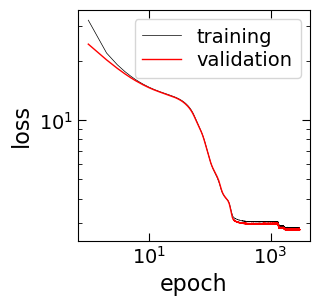

In [9]:
show_keys = ['L','wt_decay','n_layer','atypes','reg_fun']

print('Best test stat = {0:.3e}'.format(bts))
print('Setup params:')
for pkey in show_keys:
    print('... '+pkey+':',ae.params[pkey])
    if pkey == 'atypes':
        if 'lrelu' in ae.params[pkey]:
            print('... ... lrelu_slope: {0:.2e}'.format(ae.params['lrelu_slope']))
print('... check_after: {0:d}'.format(ptrain['check_after']))
print('... lrate: {0:.2e}'.format(ptrain['lrate']))

N_free = ae.net.calc_N_freeparams()
print('No. of free params optimized = {0:d}\n'.format(N_free))

plt.figure(figsize=(3,3))
plt.yscale('log')
plt.xscale('log')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.plot(ae.net.epochs,ae.net.training_loss,'k-',lw=0.5,label='training')
plt.plot(ae.net.epochs,ae.net.val_loss,'r-',lw=1,label='validation')
plt.legend()
plt.show()
